# Lab L8: From Autoencoders to Generative Latent Models — AE, VAE, and VQ-VAE on MNIST

**Course context:** DSAI5207 Deep Learning, generative modeling lab  
**Estimated time:** 2 to 3 hours for a careful first pass  
**Required background:** basic autoencoders, PyTorch training loops, neural network fundamentals, and autoregressive models

## Learning objectives
By the end of this lab, you should be able to:
1. implement and train a deterministic autoencoder, a VAE, and a VQ-VAE on MNIST,
2. explain why good reconstruction does not automatically imply good generation,
3. interpret the role of latent-space regularization in VAEs,
4. explain how vector quantization creates a discrete latent bottleneck,
5. demonstrate why naive random sampling in VQ-VAE latent space is poor,
6. train a simple autoregressive prior over VQ-VAE code indices, and
7. compare AE, VAE, VQ-VAE, and VQ-VAE plus prior both qualitatively and quantitatively.

This notebook is written as a **classroom-ready teaching tutorial**. Read the markdown carefully, run cells in order, and pause at the reflection prompts. The goal is not just to get code running, but to understand the conceptual progression:

**AE -> why AE is not enough -> VAE -> VQ-VAE -> VQ-VAE with learned prior**

## Section 0. Environment Setup and Reproducibility

Reproducibility matters in deep learning for two reasons:
1. it makes experiments easier to debug, and
2. it makes classroom discussion more meaningful because we can compare similar outcomes.

That said, reproducibility is not magic. GPU kernels, library versions, and hardware differences can still introduce small variations. Our goal here is **controlled variability**, not absolute bit-for-bit determinism across all machines.

We will:
- import the libraries we need,
- set seeds for Python, NumPy, and PyTorch,
- configure a device,
- define a small configuration system for classroom, demo, or full runs, and
- create shared helper functions for plotting, training, and evaluation.

In [2]:
import math
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import Markdown, display
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import datasets, transforms

plt.style.use("seaborn-v0_8-whitegrid")

# Runtime presets let us trade off speed versus quality without rewriting the notebook.
CONFIG_PROFILES = {
    "demo": {
        "train_subset": 6000,
        "val_subset": 1000,
        "test_subset": 1000,
        "batch_size": 128,
        "ae_epochs": 5,
        "vae_epochs": 6,
        "vqvae_epochs": 8,
        "prior_epochs": 10,
        "beta_experiment_epochs": 3,
    },
    "classroom": {
        "train_subset": 12000,
        "val_subset": 2000,
        "test_subset": 2000,
        "batch_size": 128,
        "ae_epochs": 8,
        "vae_epochs": 10,
        "vqvae_epochs": 12,
        "prior_epochs": 20,
        "beta_experiment_epochs": 4,
    },
    "full": {
        "train_subset": 55000,
        "val_subset": 5000,
        "test_subset": 10000,
        "batch_size": 128,
        "ae_epochs": 10,
        "vae_epochs": 14,
        "vqvae_epochs": 18,
        "prior_epochs": 16,
        "beta_experiment_epochs": 5,
    },
}

LAB_CONFIG = {
    "profile": "classroom",
    "seed": 5207,
    "latent_dim_ae": 2,
    "latent_dim_vae": 2,
    "hidden_dim": 256,
    "learning_rate": 1e-3,
    "weight_decay": 1e-5,
    "num_workers": 0,
    "beta": 1.0,
    "vq_num_embeddings": 64,
    "vq_embedding_dim": 16,
    "vq_commitment_cost": 0.25,
    "vq_learning_rate": 3e-4,
    "vq_grad_clip_norm": 1.0,
    "prior_embed_dim": 192,
    "prior_hidden_dim": 384,
    "prior_num_layers": 3,
    "prior_dropout": 0.15,
    "prior_learning_rate": 8e-4,
    "prior_grad_clip_norm": 1.0,
    "prior_temperature": 0.8,
    "prior_top_k": 16,
    "data_root": "./data",
}

LAB_CONFIG.update(CONFIG_PROFILES[LAB_CONFIG["profile"]])


def set_seed(seed: int = 5207):
    # We seed Python, NumPy, and PyTorch so the lab is easier to reproduce and debug.
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(LAB_CONFIG["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")
print(f"Active runtime profile: {LAB_CONFIG['profile']}")
print(
    f"Subset sizes -> train: {LAB_CONFIG['train_subset']}, "
    f"val: {LAB_CONFIG['val_subset']}, test: {LAB_CONFIG['test_subset']}"
)


Using device: cuda
Active runtime profile: classroom
Subset sizes -> train: 12000, val: 2000, test: 2000


**Think Before You Run**

If you switch from `classroom` to `full`, what changes do you expect?
- Better reconstructions?
- Better generations?
- Longer runtime?
- More stable codebook usage?

In deep learning, these usually improve together only up to a point. More training can help, but model design still matters.

In [3]:
def build_mnist_dataloaders(config):
    transform = transforms.ToTensor()
    data_root = Path(config["data_root"])
    train_full = datasets.MNIST(root=data_root, train=True, download=True, transform=transform)
    test_full = datasets.MNIST(root=data_root, train=False, download=True, transform=transform)

    rng = np.random.default_rng(config["seed"])
    train_perm = rng.permutation(len(train_full))
    test_perm = rng.permutation(len(test_full))

    n_train = config["train_subset"]
    n_val = config["val_subset"]
    n_test = config["test_subset"]

    train_indices = train_perm[:n_train]
    val_indices = train_perm[n_train : n_train + n_val]
    test_indices = test_perm[:n_test]

    train_dataset = Subset(train_full, train_indices.tolist())
    val_dataset = Subset(train_full, val_indices.tolist())
    test_dataset = Subset(test_full, test_indices.tolist())

    # We keep a second non-shuffled training loader for code extraction and visual analysis.
    train_loader = DataLoader(
        train_dataset,
        batch_size=config["batch_size"],
        shuffle=True,
        num_workers=config["num_workers"],
    )
    train_eval_loader = DataLoader(
        train_dataset,
        batch_size=config["batch_size"],
        shuffle=False,
        num_workers=config["num_workers"],
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=config["batch_size"],
        shuffle=False,
        num_workers=config["num_workers"],
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=config["batch_size"],
        shuffle=False,
        num_workers=config["num_workers"],
    )

    return {
        "train_dataset": train_dataset,
        "val_dataset": val_dataset,
        "test_dataset": test_dataset,
        "train_loader": train_loader,
        "train_eval_loader": train_eval_loader,
        "val_loader": val_loader,
        "test_loader": test_loader,
    }


def sample_from_dataset(dataset, n=16, seed=0):
    rng = np.random.default_rng(seed)
    indices = rng.choice(len(dataset), size=n, replace=False)
    images = torch.stack([dataset[i][0] for i in indices])
    labels = torch.tensor([dataset[i][1] for i in indices])
    return images, labels


def plot_digit_grid(images, labels=None, title="", ncols=8, cmap="gray"):
    images = images.detach().cpu()
    n = len(images)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(1.6 * ncols, 1.8 * nrows))
    axes = np.array(axes).reshape(nrows, ncols)
    for ax in axes.flat:
        ax.axis("off")
    for i in range(n):
        ax = axes.flat[i]
        ax.imshow(images[i, 0], cmap=cmap, vmin=0.0, vmax=1.0)
        if labels is not None:
            ax.set_title(f"label={int(labels[i])}", fontsize=9)
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


def plot_reconstructions(inputs, reconstructions, title="Reconstructions", n=8):
    inputs = inputs[:n].detach().cpu()
    reconstructions = reconstructions[:n].detach().cpu()
    fig, axes = plt.subplots(2, n, figsize=(1.8 * n, 4))
    for i in range(n):
        axes[0, i].imshow(inputs[i, 0], cmap="gray", vmin=0.0, vmax=1.0)
        axes[0, i].axis("off")
        axes[0, i].set_title(f"Input {i+1}")

        axes[1, i].imshow(reconstructions[i, 0], cmap="gray", vmin=0.0, vmax=1.0)
        axes[1, i].axis("off")
        axes[1, i].set_title(f"Recon {i+1}")
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


def plot_loss_curves(history, title="Training curves"):
    plt.figure(figsize=(8, 4.5))
    for key, values in history.items():
        plt.plot(values, marker="o", label=key)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_latent_scatter(z, labels, title="Latent space"):
    z = z.detach().cpu().numpy()
    labels = labels.detach().cpu().numpy()
    plt.figure(figsize=(6.5, 5.5))
    scatter = plt.scatter(z[:, 0], z[:, 1], c=labels, cmap="tab10", s=10, alpha=0.8)
    plt.colorbar(scatter, ticks=list(range(10)), label="Digit label")
    plt.xlabel("Latent dimension 1")
    plt.ylabel("Latent dimension 2")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def pca_project(array, n_components=2):
    if torch.is_tensor(array):
        x = array.detach().cpu().numpy()
    else:
        x = np.asarray(array)
    x = x - x.mean(axis=0, keepdims=True)
    _, _, vt = np.linalg.svd(x, full_matrices=False)
    return x @ vt[:n_components].T


def maybe_apply_pca(z, n_components=2):
    if z.shape[1] == n_components:
        return z
    return torch.tensor(pca_project(z, n_components=n_components), dtype=torch.float32)


def show_latent_grid(decoder_fn, x_range=(-3, 3), y_range=(-3, 3), steps=12, title="Decoded latent grid"):
    xs = torch.linspace(x_range[0], x_range[1], steps)
    ys = torch.linspace(y_range[0], y_range[1], steps)
    coords = []
    for y in reversed(ys):
        for x in xs:
            coords.append(torch.tensor([x, y], dtype=torch.float32))
    z = torch.stack(coords).to(device)
    with torch.no_grad():
        images = decoder_fn(z).detach().cpu()
    canvas = torch.zeros(steps * 28, steps * 28)
    idx = 0
    for i in range(steps):
        for j in range(steps):
            canvas[i * 28 : (i + 1) * 28, j * 28 : (j + 1) * 28] = images[idx, 0]
            idx += 1
    plt.figure(figsize=(9, 9))
    plt.imshow(canvas, cmap="gray", vmin=0.0, vmax=1.0)
    plt.title(title)
    plt.axis("off")
    plt.show()


@torch.no_grad()
def evaluate_reconstruction_metrics(model, loader, model_type="ae"):
    model.eval()
    total_bce = 0.0
    total_mse = 0.0
    total_n = 0
    for x, _ in loader:
        x = x.to(device)
        if model_type == "ae":
            recon = model(x)
        elif model_type == "vae":
            recon, _, _ = model(x, sample_posterior=False)
        elif model_type == "vqvae":
            recon, _, _, _, _, _ = model(x)
        else:
            raise ValueError(f"Unknown model_type: {model_type}")

        total_bce += F.binary_cross_entropy(recon, x, reduction="sum").item()
        total_mse += F.mse_loss(recon, x, reduction="sum").item()
        total_n += x.size(0)

    return {
        "bce_per_image": total_bce / total_n,
        "mse_per_image": total_mse / total_n,
    }


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


## Section 1. Explore the MNIST Dataset

MNIST is a classic benchmark of grayscale handwritten digits. Every image is $28 \times 28$, but the digits vary in many ways:
- stroke thickness,
- writing angle,
- digit style,
- size and centering,
- small gaps or loops,
- and overall neatness.

A useful latent model should compress these variations into a representation that keeps the important structure while discarding irrelevant noise.

**Think Before You Run**

Before looking at the data, ask yourself:
1. Which kinds of variation should a latent representation preserve?
2. Which kinds of variation should it ignore?
3. If two different $2$s look quite different, should their latent codes still be close together?


100%|██████████| 9.91M/9.91M [00:02<00:00, 4.67MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 131kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.22MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.00MB/s]


Train subset size: 12000
Validation subset size: 2000
Test subset size: 2000


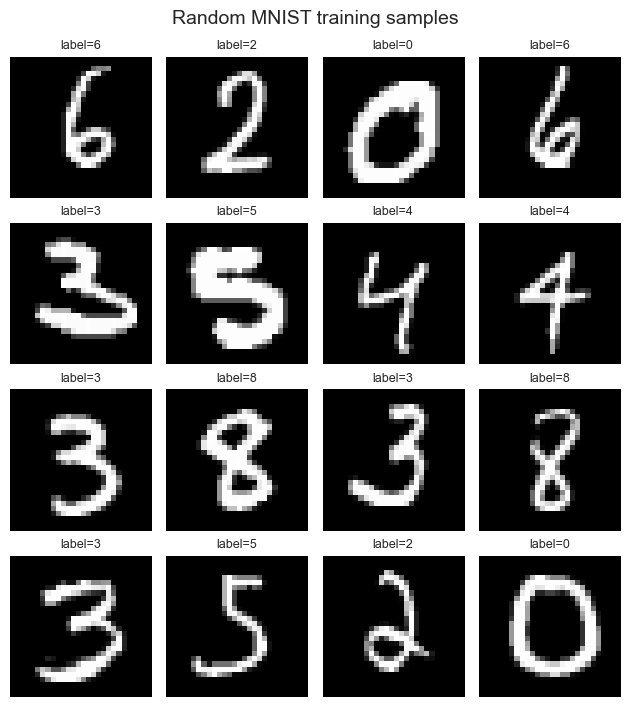

In [4]:
# This cell materializes the data split so every later section can reuse the same loaders.
mnist_data = build_mnist_dataloaders(LAB_CONFIG)
train_dataset = mnist_data["train_dataset"]
val_dataset = mnist_data["val_dataset"]
test_dataset = mnist_data["test_dataset"]
train_loader = mnist_data["train_loader"]
train_eval_loader = mnist_data["train_eval_loader"]
val_loader = mnist_data["val_loader"]
test_loader = mnist_data["test_loader"]

print(f"Train subset size: {len(train_dataset)}")
print(f"Validation subset size: {len(val_dataset)}")
print(f"Test subset size: {len(test_dataset)}")

sample_images, sample_labels = sample_from_dataset(train_dataset, n=16, seed=LAB_CONFIG["seed"])
plot_digit_grid(sample_images, sample_labels, title="Random MNIST training samples", ncols=4)


**Interpretation prompt**

Look at the same digit class across different samples. Which differences are superficial style variations, and which differences might make classification or generation genuinely harder?

### Checkpoint Summary
At this point we have a reproducible data pipeline, classroom-sized train/validation/test splits, and a visual feel for the structure of MNIST. Next we begin with the simplest latent model: a deterministic autoencoder.

## Section 2. Warm-up Baseline: Simple Autoencoder on MNIST

A deterministic autoencoder consists of:
- an **encoder** that maps an image $x$ to a latent code $z$, and
- a **decoder** that maps the latent code back to a reconstruction $\hat{x}$.

The training goal is straightforward: make $\hat{x}$ as close as possible to $x$.

This is excellent for **representation learning** and **compression**, but it does **not** automatically give us a principled generative model. We will see that tension very clearly once we inspect the latent space.


In [5]:
class AEEncoder(nn.Module):
    def __init__(self, latent_dim=2, hidden_dim=256):
        super().__init__()
        # A small fully connected encoder is enough for MNIST and keeps the math transparent.
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim),
        )

    def forward(self, x):
        return self.net(x)


class AEDecoder(nn.Module):
    def __init__(self, latent_dim=2, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 28 * 28),
            nn.Sigmoid(),
        )

    def forward(self, z):
        x_hat = self.net(z)
        return x_hat.view(-1, 1, 28, 28)


class Autoencoder(nn.Module):
    def __init__(self, latent_dim=2, hidden_dim=256):
        super().__init__()
        self.encoder = AEEncoder(latent_dim=latent_dim, hidden_dim=hidden_dim)
        self.decoder = AEDecoder(latent_dim=latent_dim, hidden_dim=hidden_dim)

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z)


def train_autoencoder(model, train_loader, val_loader, epochs=8, lr=1e-3, weight_decay=1e-5):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    history = {"train_bce": [], "val_bce": []}

    for epoch in range(epochs):
        model.train()
        running_train = 0.0
        train_n = 0
        for x, _ in train_loader:
            x = x.to(device)
            recon = model(x)
            # BCE is averaged per image so losses are easy to compare across batch sizes.
            loss = F.binary_cross_entropy(recon, x, reduction="sum") / x.size(0)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_train += loss.item() * x.size(0)
            train_n += x.size(0)

        model.eval()
        running_val = 0.0
        val_n = 0
        with torch.no_grad():
            for x, _ in val_loader:
                x = x.to(device)
                recon = model(x)
                loss = F.binary_cross_entropy(recon, x, reduction="sum") / x.size(0)
                running_val += loss.item() * x.size(0)
                val_n += x.size(0)

        history["train_bce"].append(running_train / train_n)
        history["val_bce"].append(running_val / val_n)
        print(
            f"[AE] Epoch {epoch + 1:02d}/{epochs} | "
            f"train BCE: {history['train_bce'][-1]:.4f} | "
            f"val BCE: {history['val_bce'][-1]:.4f}"
        )
    return history


@torch.no_grad()
def collect_ae_latents(model, loader):
    zs, labels = [], []
    model.eval()
    for x, y in loader:
        x = x.to(device)
        z = model.encode(x)
        zs.append(z.cpu())
        labels.append(y.cpu())
    return torch.cat(zs, dim=0), torch.cat(labels, dim=0)


The implementation above is intentionally small and readable. Notice the design choices:
- the encoder is fully connected because MNIST is small,
- the latent dimension is only $2$, so we can visualize it directly,
- the decoder ends with a sigmoid because pixel values lie in $[0, 1]$.

**Why BCE instead of L2 here?**

For MNIST, the pixels lie in $[0, 1]$ and are close to binary foreground-versus-background values. Using **binary cross-entropy (BCE)** corresponds to modeling each pixel with a Bernoulli likelihood, which matches the usual interpretation of a sigmoid decoder output as a probability.

If we used **L2 / MSE** instead, we would be assuming a Gaussian likelihood over pixel intensities. That is also a valid choice, but it encodes a different observation model. In this lab we use BCE because it is a natural fit for MNIST and it connects cleanly to the probabilistic interpretation of the VAE reconstruction term.

**Common Pitfall**

Students sometimes assume that a low reconstruction loss means the model has learned a good generative space. That is **not** guaranteed. Reconstruction quality only tells us how well the decoder can invert the encoder on the training distribution.


AE trainable parameters: 535,314
[AE] Epoch 01/8 | train BCE: 236.4550 | val BCE: 192.3901
[AE] Epoch 02/8 | train BCE: 181.5825 | val BCE: 174.0598
[AE] Epoch 03/8 | train BCE: 168.8055 | val BCE: 165.6975
[AE] Epoch 04/8 | train BCE: 162.7657 | val BCE: 162.1550
[AE] Epoch 05/8 | train BCE: 159.5471 | val BCE: 159.0815
[AE] Epoch 06/8 | train BCE: 157.3925 | val BCE: 157.5899
[AE] Epoch 07/8 | train BCE: 155.6455 | val BCE: 156.4779
[AE] Epoch 08/8 | train BCE: 154.2473 | val BCE: 154.6360


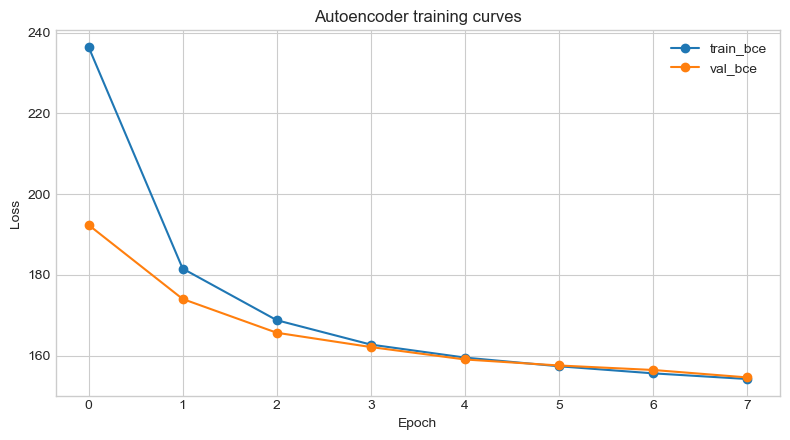

In [6]:
# Train the deterministic autoencoder baseline first so we have a reconstruction reference.
ae = Autoencoder(
    latent_dim=LAB_CONFIG["latent_dim_ae"],
    hidden_dim=LAB_CONFIG["hidden_dim"],
).to(device)

print(f"AE trainable parameters: {count_parameters(ae):,}")
ae_history = train_autoencoder(
    ae,
    train_loader,
    val_loader,
    epochs=LAB_CONFIG["ae_epochs"],
    lr=LAB_CONFIG["learning_rate"],
    weight_decay=LAB_CONFIG["weight_decay"],
)
plot_loss_curves(ae_history, title="Autoencoder training curves")


**Interpretation prompt**

Compare the training and validation curves. Are they moving together, or is there a growing gap? What does that suggest about generalization versus memorization?

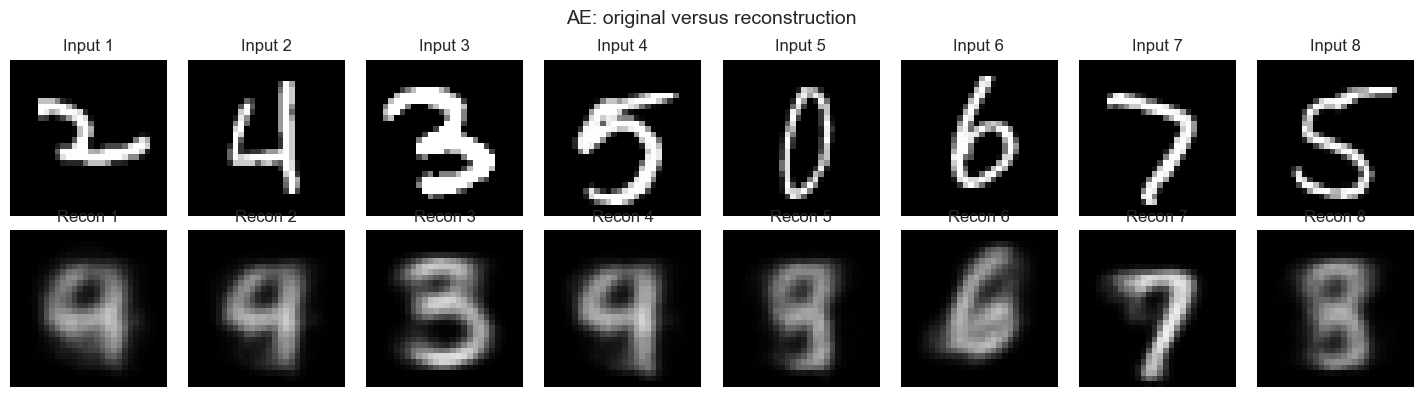

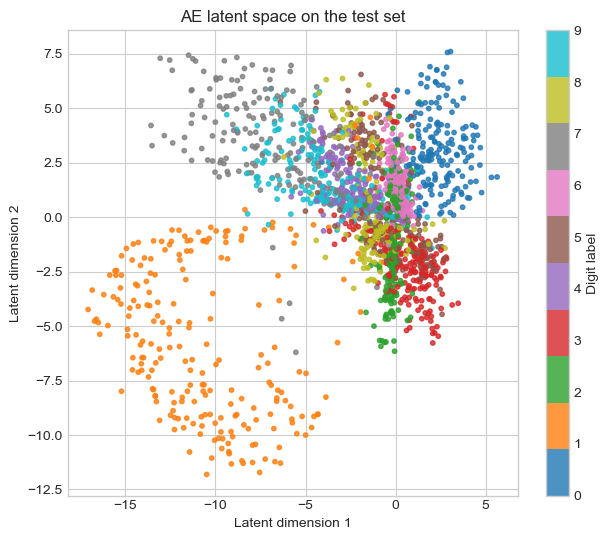

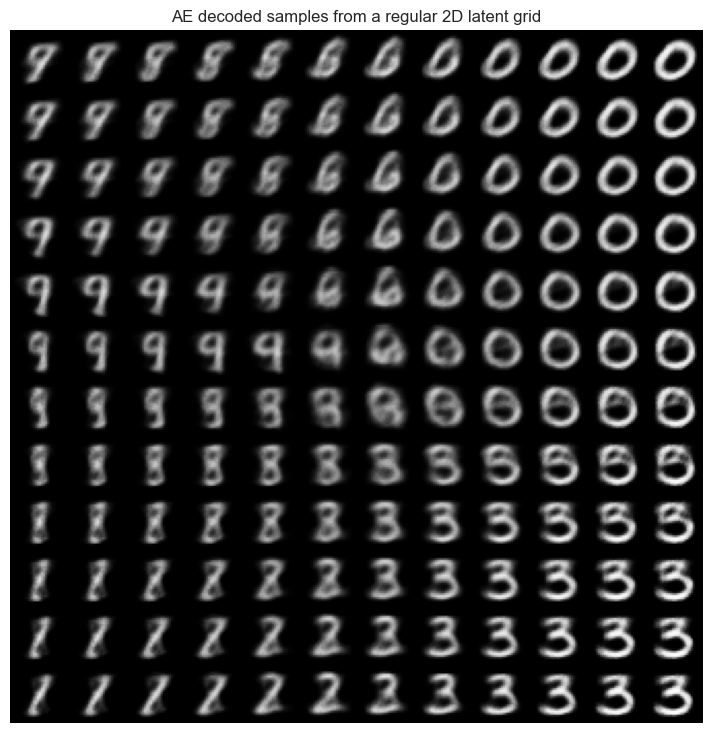

In [7]:
# We inspect both reconstructions and latent geometry because low loss alone is not enough.
ae_test_batch, ae_test_labels = next(iter(test_loader))
ae_test_batch = ae_test_batch.to(device)
with torch.no_grad():
    ae_recon = ae(ae_test_batch)
plot_reconstructions(ae_test_batch, ae_recon, title="AE: original versus reconstruction", n=8)

ae_latents, ae_latent_labels = collect_ae_latents(ae, test_loader)
ae_latents_2d = maybe_apply_pca(ae_latents, n_components=2)
plot_latent_scatter(ae_latents_2d, ae_latent_labels, title="AE latent space on the test set")

# Decoding a regular latent grid is a quick way to test whether random latent points are meaningful.
show_latent_grid(
    ae.decode,
    x_range=(-4, 4),
    y_range=(-4, 4),
    steps=12,
    title="AE decoded samples from a regular 2D latent grid",
)


**Interpretation prompt**

Look at the decoded latent grid. Do all regions produce realistic digits? Are there blank zones, distorted shapes, or sudden transitions? That is our first sign that the AE latent space is not automatically organized for random generation.

### Checkpoint Summary
The AE can reconstruct test digits reasonably well and provides a visible 2D latent organization. However, random locations in latent space are not guaranteed to correspond to realistic images, because the encoder never had to match a known prior distribution.

## Section 3. Why AE Is Not Enough for Generative Modeling

The autoencoder learned a **deterministic code** for each input, but it did **not** learn a rule saying where valid latent codes should live.

Three conceptual issues appear immediately:

1. **Deterministic encoding**  
   Each input maps to one point in latent space. There is no uncertainty model.

2. **No prior regularization**  
   The model is never told to arrange codes according to a simple distribution such as a Gaussian.

3. **Poor random sampling behavior**  
   If we sample latent points arbitrarily, we may land in holes between encoded examples, and the decoder may output blurry or unrealistic images.

This is why a strong autoencoder is not automatically a strong generative model.

**Think Before You Run**

1. If two latent points reconstruct real digits, does every point between them also reconstruct a real digit?
2. What kind of extra constraint would make random sampling more meaningful?
3. If we want to sample by drawing $z$ from a simple distribution, what must training encourage the latent codes to look like?


## Section 4. Variational Autoencoder (VAE): Theory Recap

A VAE addresses the weakness of the deterministic AE by turning the latent code into a **distribution** instead of a single point.

### Why do we need a VAE?
We want a model that can:
- reconstruct inputs well, and
- support principled generation from a simple prior such as $z \sim \mathcal{N}(0, I)$.

To make that possible, we encourage the latent representations of data to stay close to a Gaussian prior.

### Approximate posterior intuition
Instead of encoding an image into one vector, the encoder predicts the parameters of a distribution:
- a mean $\mu$, and
- a log-variance $\log \sigma^2$.

This gives an approximate posterior:

$$
q_\phi(z \mid x) = \mathcal{N}\bigl(z; \mu(x), \operatorname{diag}(\sigma^2(x))\bigr)
$$

In code, we usually store the log-variance as `logvar`, meaning:

$$
\text{logvar} = \log(\sigma^2)
$$

### Reparameterization trick
We still need gradients to flow through the sampling step. Instead of sampling $z$ directly from a distribution object, we rewrite:

$$
z = \mu + \sigma \odot \epsilon, \qquad \epsilon \sim \mathcal{N}(0, I)
$$

Now the randomness is isolated in $\epsilon$, and $\mu$ and $\sigma$ remain differentiable.

### ELBO objective
The VAE optimizes the Evidence Lower Bound (ELBO), typically written as:

$$
\mathcal{L}_{\text{ELBO}} = \mathbb{E}_{q_\phi(z \mid x)}\bigl[\log p_\theta(x \mid z)\bigr] - D_{\mathrm{KL}}\bigl(q_\phi(z \mid x) \| p(z)\bigr)
$$

In practice we **minimize** the negative ELBO, which becomes:
- a **reconstruction term**: make reconstructions match the input,
- a **KL divergence term**: keep the approximate posterior close to the Gaussian prior.

Intuitively:
- the reconstruction term says, "Do not forget the image."
- the KL term says, "Do not make the latent space arbitrary."

### Common Pitfalls
- `logvar` is **not** the standard deviation; it is the logarithm of the variance.
- If the KL term is too weak, the VAE behaves too much like a plain autoencoder.
- If the KL term is too strong, reconstructions may become overly blurry or uninformative.
- A pretty 2D latent plot is helpful, but it is not the whole story.

### Checkpoint Summary
The VAE adds probabilistic structure to the latent space so that sampling from a simple prior is meaningful. This is the key conceptual move that transforms an encoder-decoder from a reconstruction model into a generative latent model.


In [8]:
class VAEEncoder(nn.Module):
    def __init__(self, latent_dim=2, hidden_dim=256):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        # The encoder predicts a Gaussian posterior q(z|x) through its mean and log-variance.
        self.mu_head = nn.Linear(hidden_dim, latent_dim)
        self.logvar_head = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):
        h = self.shared(x)
        return self.mu_head(h), self.logvar_head(h)


class VAEDecoder(nn.Module):
    def __init__(self, latent_dim=2, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 28 * 28),
            nn.Sigmoid(),
        )

    def forward(self, z):
        x_hat = self.net(z)
        return x_hat.view(-1, 1, 28, 28)


class VAE(nn.Module):
    def __init__(self, latent_dim=2, hidden_dim=256):
        super().__init__()
        self.encoder = VAEEncoder(latent_dim=latent_dim, hidden_dim=hidden_dim)
        self.decoder = VAEDecoder(latent_dim=latent_dim, hidden_dim=hidden_dim)
        self.latent_dim = latent_dim

    def reparameterize(self, mu, logvar):
        # Reparameterization moves randomness into eps so gradients can still flow to mu/logvar.
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    def forward(self, x, sample_posterior=True):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar) if sample_posterior else mu
        recon = self.decoder(z)
        return recon, mu, logvar

    def sample_prior(self, num_samples):
        z = torch.randn(num_samples, self.latent_dim, device=device)
        return self.decoder(z)


def vae_loss(x, recon, mu, logvar, beta=1.0):
    recon_loss = F.binary_cross_entropy(recon, x, reduction="sum") / x.size(0)
    # KL is averaged over the batch so it can be tracked on the same scale as recon loss.
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1).mean()
    total = recon_loss + beta * kl
    return total, recon_loss, kl


def train_vae(model, train_loader, val_loader, epochs=10, lr=1e-3, weight_decay=1e-5, beta=1.0):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    history = {
        "train_total": [],
        "train_recon": [],
        "train_kl": [],
        "val_total": [],
        "val_recon": [],
        "val_kl": [],
    }

    for epoch in range(epochs):
        model.train()
        accum = {key: 0.0 for key in ["total", "recon", "kl"]}
        train_n = 0
        for x, _ in train_loader:
            x = x.to(device)
            recon, mu, logvar = model(x, sample_posterior=True)
            total, recon_loss, kl = vae_loss(x, recon, mu, logvar, beta=beta)

            optimizer.zero_grad()
            total.backward()
            optimizer.step()

            batch_size = x.size(0)
            accum["total"] += total.item() * batch_size
            accum["recon"] += recon_loss.item() * batch_size
            accum["kl"] += kl.item() * batch_size
            train_n += batch_size

        model.eval()
        val_accum = {key: 0.0 for key in ["total", "recon", "kl"]}
        val_n = 0
        with torch.no_grad():
            for x, _ in val_loader:
                x = x.to(device)
                recon, mu, logvar = model(x, sample_posterior=False)
                total, recon_loss, kl = vae_loss(x, recon, mu, logvar, beta=beta)
                batch_size = x.size(0)
                val_accum["total"] += total.item() * batch_size
                val_accum["recon"] += recon_loss.item() * batch_size
                val_accum["kl"] += kl.item() * batch_size
                val_n += batch_size

        history["train_total"].append(accum["total"] / train_n)
        history["train_recon"].append(accum["recon"] / train_n)
        history["train_kl"].append(accum["kl"] / train_n)
        history["val_total"].append(val_accum["total"] / val_n)
        history["val_recon"].append(val_accum["recon"] / val_n)
        history["val_kl"].append(val_accum["kl"] / val_n)

        print(
            f"[VAE] Epoch {epoch + 1:02d}/{epochs} | "
            f"train total: {history['train_total'][-1]:.4f} | "
            f"train recon: {history['train_recon'][-1]:.4f} | "
            f"train kl: {history['train_kl'][-1]:.4f} | "
            f"val total: {history['val_total'][-1]:.4f}"
        )
    return history


@torch.no_grad()
def collect_vae_latents(model, loader):
    mus, labels = [], []
    model.eval()
    for x, y in loader:
        x = x.to(device)
        mu, _ = model.encoder(x)
        mus.append(mu.cpu())
        labels.append(y.cpu())
    return torch.cat(mus, dim=0), torch.cat(labels, dim=0)


@torch.no_grad()
def interpolate_vae(model, x_a, x_b, steps=10):
    mu_a, _ = model.encoder(x_a)
    mu_b, _ = model.encoder(x_b)
    alphas = torch.linspace(0, 1, steps, device=device)
    zs = torch.stack([(1 - a) * mu_a.squeeze(0) + a * mu_b.squeeze(0) for a in alphas], dim=0)
    return model.decoder(zs)


## Section 5. Full Implementation of VAE on MNIST

Our VAE code closely mirrors the theory:
- the encoder outputs $\mu$ and `logvar`,
- the reparameterization trick creates a stochastic latent sample,
- the decoder reconstructs the image,
- the loss combines reconstruction and KL regularization.

Notice that we track the reconstruction and KL terms separately. This matters because a single scalar loss can hide whether the model is reconstructing well by ignoring the prior, or matching the prior while reconstructing poorly.


VAE trainable parameters: 535,828
[VAE] Epoch 01/10 | train total: 237.2627 | train recon: 234.6130 | train kl: 2.6497 | val total: 193.1833
[VAE] Epoch 02/10 | train total: 184.2725 | train recon: 180.8000 | train kl: 3.4726 | val total: 176.4424
[VAE] Epoch 03/10 | train total: 173.7760 | train recon: 169.3494 | train kl: 4.4266 | val total: 170.6572
[VAE] Epoch 04/10 | train total: 169.7909 | train recon: 165.1065 | train kl: 4.6843 | val total: 168.2264
[VAE] Epoch 05/10 | train total: 167.5357 | train recon: 162.7453 | train kl: 4.7905 | val total: 166.0934
[VAE] Epoch 06/10 | train total: 165.5285 | train recon: 160.5966 | train kl: 4.9319 | val total: 164.3276
[VAE] Epoch 07/10 | train total: 163.5034 | train recon: 158.3808 | train kl: 5.1226 | val total: 162.5878
[VAE] Epoch 08/10 | train total: 161.2250 | train recon: 155.9628 | train kl: 5.2623 | val total: 160.8616
[VAE] Epoch 09/10 | train total: 159.5810 | train recon: 154.1721 | train kl: 5.4089 | val total: 159.8613
[VA

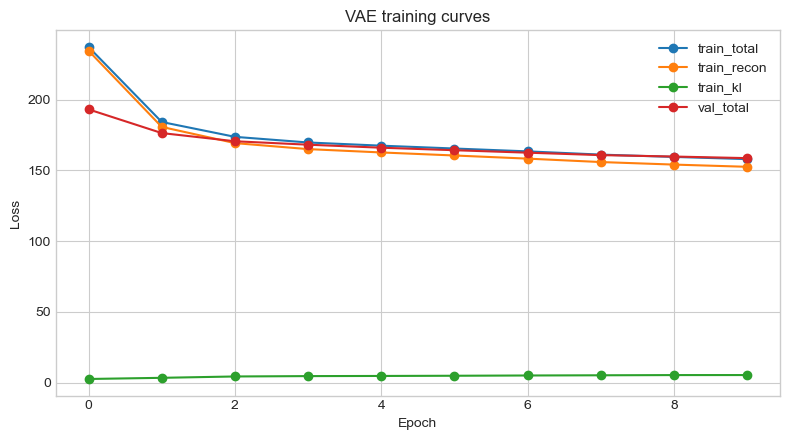

VAE test metrics:
  bce_per_image: 152.5568
  mse_per_image: 35.2467


In [9]:
# The VAE is trained after the AE so students can compare reconstruction quality and latent structure.
vae = VAE(
    latent_dim=LAB_CONFIG["latent_dim_vae"],
    hidden_dim=LAB_CONFIG["hidden_dim"],
).to(device)

print(f"VAE trainable parameters: {count_parameters(vae):,}")
vae_history = train_vae(
    vae,
    train_loader,
    val_loader,
    epochs=LAB_CONFIG["vae_epochs"],
    lr=LAB_CONFIG["learning_rate"],
    weight_decay=LAB_CONFIG["weight_decay"],
    beta=LAB_CONFIG["beta"],
)
plot_loss_curves(
    {
        "train_total": vae_history["train_total"],
        "train_recon": vae_history["train_recon"],
        "train_kl": vae_history["train_kl"],
        "val_total": vae_history["val_total"],
    },
    title="VAE training curves",
)

vae_metrics = evaluate_reconstruction_metrics(vae, test_loader, model_type="vae")
print("VAE test metrics:")
for key, value in vae_metrics.items():
    print(f"  {key}: {value:.4f}")


**Interpretation prompt**

Is the KL term near zero, or does it stay meaningfully active? A near-zero KL can mean the model is behaving too much like a deterministic autoencoder.

## Section 6. VAE Evaluation, Visualization, and Generation

Now we test whether the VAE actually behaves like a **generative latent model**.

We will inspect:
- reconstructions,
- samples from the Gaussian prior,
- the latent organization of test digits,
- latent interpolation between digits, and
- a small $\beta$-VAE style experiment.


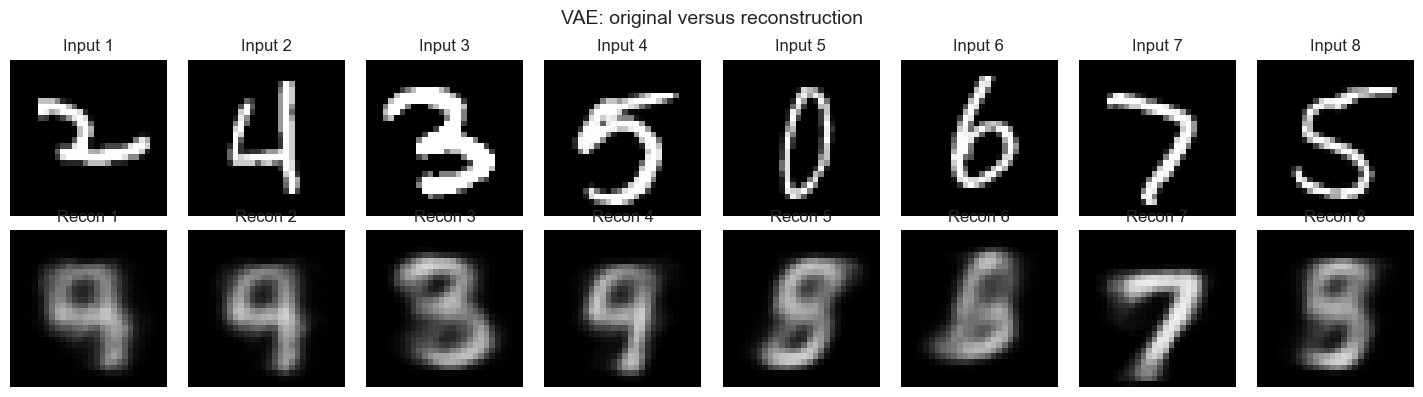

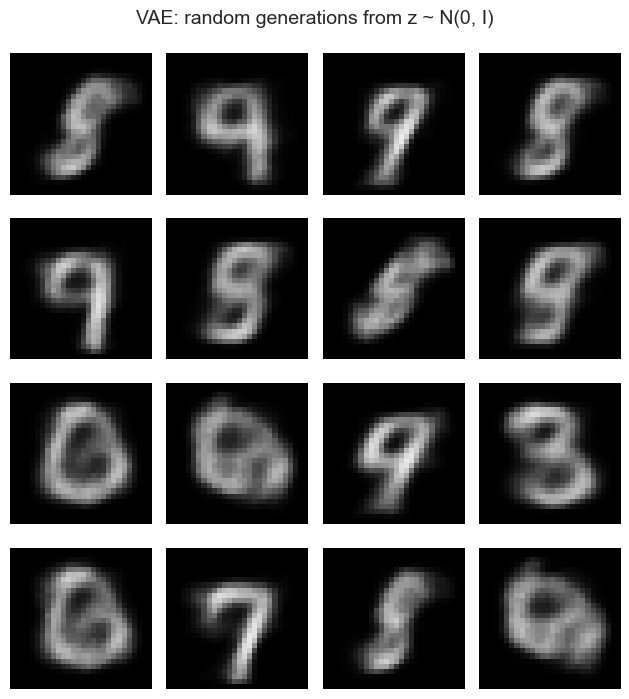

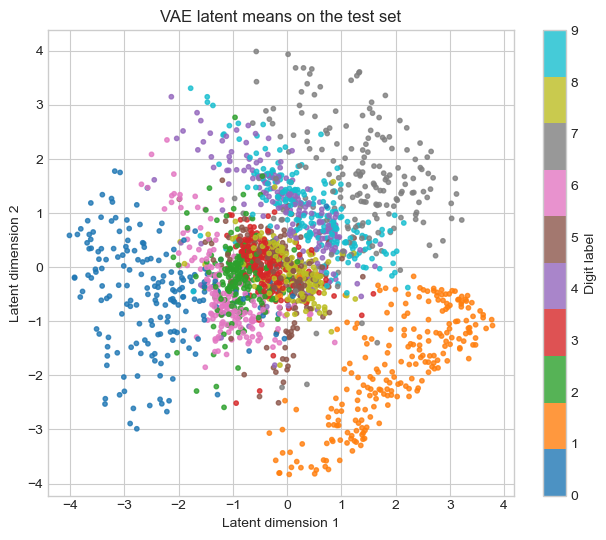

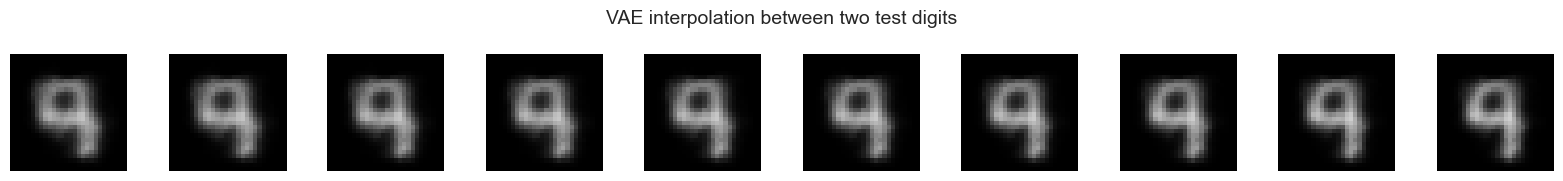

In [10]:
# This cell checks whether the learned Gaussian latent space supports reconstruction and generation.
vae_test_batch, vae_test_labels = next(iter(test_loader))
vae_test_batch = vae_test_batch.to(device)
with torch.no_grad():
    vae_recon, vae_mu, vae_logvar = vae(vae_test_batch, sample_posterior=False)
    vae_samples = vae.sample_prior(16)

plot_reconstructions(vae_test_batch, vae_recon, title="VAE: original versus reconstruction", n=8)
plot_digit_grid(vae_samples, title="VAE: random generations from z ~ N(0, I)", ncols=4)

vae_latents, vae_latent_labels = collect_vae_latents(vae, test_loader)
vae_latents_2d = maybe_apply_pca(vae_latents, n_components=2)
plot_latent_scatter(vae_latents_2d, vae_latent_labels, title="VAE latent means on the test set")

# Interpolation reveals whether nearby latent points decode to a smooth semantic transition.
interp_source = test_dataset[0][0].unsqueeze(0).to(device)
interp_target = test_dataset[1][0].unsqueeze(0).to(device)
interp_images = interpolate_vae(vae, interp_source, interp_target, steps=10)
plot_digit_grid(interp_images, title="VAE interpolation between two test digits", ncols=10)


**Interpretation prompt**

Compare VAE prior samples to AE random latent decodes. Which one looks more coherent across the whole grid? Why does the Gaussian prior make a difference?

**Interpretation prompt**

During interpolation, do you see smooth style changes, abrupt category switches, or implausible in-between digits? Interpolation is a useful qualitative probe of latent geometry.

[VAE] Epoch 01/4 | train total: 302.4483 | train recon: 298.9864 | train kl: 6.9238 | val total: 210.4934
[VAE] Epoch 02/4 | train total: 205.7781 | train recon: 203.8983 | train kl: 3.7596 | val total: 199.8742
[VAE] Epoch 03/4 | train total: 196.2007 | train recon: 194.1693 | train kl: 4.0629 | val total: 191.6409
[VAE] Epoch 04/4 | train total: 188.1711 | train recon: 186.0426 | train kl: 4.2570 | val total: 183.6750
[VAE] Epoch 01/4 | train total: 303.9026 | train recon: 298.4824 | train kl: 5.4202 | val total: 210.0097
[VAE] Epoch 02/4 | train total: 206.3533 | train recon: 204.0628 | train kl: 2.2905 | val total: 200.2320
[VAE] Epoch 03/4 | train total: 196.5844 | train recon: 194.0374 | train kl: 2.5470 | val total: 192.2308
[VAE] Epoch 04/4 | train total: 190.2869 | train recon: 187.5727 | train kl: 2.7142 | val total: 186.6897
[VAE] Epoch 01/4 | train total: 305.3623 | train recon: 298.0483 | train kl: 3.6570 | val total: 209.1373
[VAE] Epoch 02/4 | train total: 207.4720 | tra

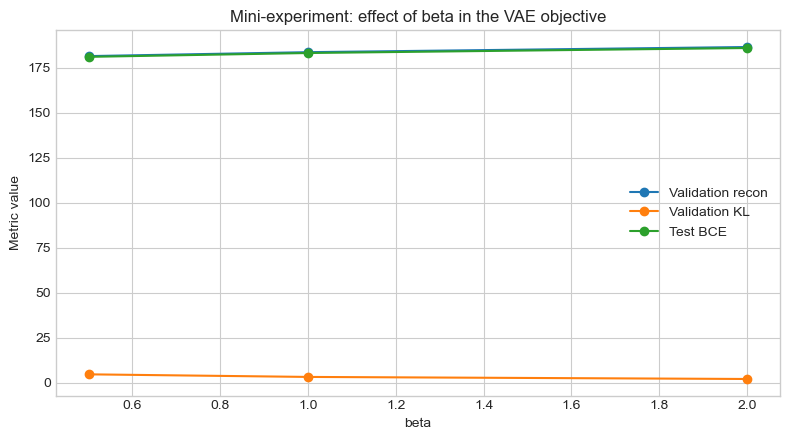

beta=0.5 | val_recon=181.4011 | val_kl=4.5477 | test_bce=180.9860
beta=1.0 | val_recon=183.5867 | val_kl=3.1030 | test_bce=183.1173
beta=2.0 | val_recon=186.4544 | val_kl=1.9628 | test_bce=185.8922


In [11]:
# A short beta sweep helps students see the tension between reconstruction quality and latent regularization.
beta_values = [0.5, 1.0, 2.0]
beta_results = []

small_train_subset = Subset(train_dataset, list(range(min(4000, len(train_dataset)))))
small_val_subset = Subset(val_dataset, list(range(min(1000, len(val_dataset)))))
small_train_loader = DataLoader(small_train_subset, batch_size=LAB_CONFIG["batch_size"], shuffle=True)
small_val_loader = DataLoader(small_val_subset, batch_size=LAB_CONFIG["batch_size"], shuffle=False)

for beta in beta_values:
    set_seed(LAB_CONFIG["seed"])
    model = VAE(
        latent_dim=LAB_CONFIG["latent_dim_vae"],
        hidden_dim=LAB_CONFIG["hidden_dim"],
    ).to(device)
    history = train_vae(
        model,
        small_train_loader,
        small_val_loader,
        epochs=LAB_CONFIG["beta_experiment_epochs"],
        lr=LAB_CONFIG["learning_rate"],
        weight_decay=LAB_CONFIG["weight_decay"],
        beta=beta,
    )
    metrics = evaluate_reconstruction_metrics(model, test_loader, model_type="vae")
    beta_results.append(
        {
            "beta": beta,
            "val_total": history["val_total"][-1],
            "val_recon": history["val_recon"][-1],
            "val_kl": history["val_kl"][-1],
            "test_bce": metrics["bce_per_image"],
        }
    )

plt.figure(figsize=(8, 4.5))
plt.plot(beta_values, [row["val_recon"] for row in beta_results], marker="o", label="Validation recon")
plt.plot(beta_values, [row["val_kl"] for row in beta_results], marker="o", label="Validation KL")
plt.plot(beta_values, [row["test_bce"] for row in beta_results], marker="o", label="Test BCE")
plt.xlabel("beta")
plt.ylabel("Metric value")
plt.title("Mini-experiment: effect of beta in the VAE objective")
plt.legend()
plt.tight_layout()
plt.show()

for row in beta_results:
    print(
        f"beta={row['beta']:.1f} | val_recon={row['val_recon']:.4f} | "
        f"val_kl={row['val_kl']:.4f} | test_bce={row['test_bce']:.4f}"
    )


**Interpretation prompt**

As $\beta$ increases, what happens to the balance between reconstruction fidelity and latent regularity? This is a controlled way to see the tension inside the ELBO.

### Checkpoint Summary
The VAE trades some reconstruction sharpness for a more structured latent space. That trade-off is exactly what makes principled random generation possible.


## Section 7. Vector Quantized VAE (VQ-VAE): Theory Recap

So far our latent variables have been **continuous**. VQ-VAE changes the story by using a **discrete latent representation**.

### Why are discrete latents interesting?
Discrete latents are useful when we want:
- compact symbolic bottlenecks,
- representations that resemble tokens or code indices,
- and compatibility with autoregressive sequence models.

### VQ-VAE pipeline
1. The encoder produces a continuous latent map.
2. Each latent vector is replaced by its nearest entry in a learned **codebook**.
3. The decoder reconstructs the image from the quantized latent map.

### Nearest-neighbor assignment
If the codebook contains embedding vectors $e_1, \\ldots, e_K$, each encoder output vector is replaced by the nearest codebook vector under Euclidean distance.

### Training losses
VQ-VAE uses three ingredients:
- a reconstruction loss,
- a **codebook loss** that moves embeddings toward encoder outputs,
- a **commitment loss** that encourages encoder outputs to stay close to the chosen codebook vectors.

### Straight-through estimator intuition
Quantization uses a discrete nearest-neighbor lookup, which is not naturally differentiable. The straight-through estimator lets gradients flow to the encoder as if the quantization step were the identity during backpropagation.

### Important conceptual distinction
A vanilla VAE comes with a simple prior, usually $\mathcal{N}(0, I)$, so sampling is immediate.

A VQ-VAE **does not** automatically solve the sampling problem. After training, we know how to reconstruct from code indices, but we still need a good model for the **distribution over code-index grids**.

### Why can VQ-VAE training become unstable?
If the encoder outputs live on a very different scale from the codebook embeddings, the nearest-neighbor assignments can become erratic. In practice, this often shows up as:
- codebook loss staying large,
- commitment loss staying large,
- codebook usage collapsing to a few entries, or
- reconstructions improving only slowly.

To make the classroom version more stable, the implementation below uses a normalization layer around the quantization bottleneck, a small projection layer before quantization, a slightly smaller learning rate for the VQ-VAE, and gradient clipping during training.

### Common Pitfalls
- Confusing the codebook with a generative prior.
- Thinking that independent random code sampling should work well.
- Forgetting that a spatial grid of indices has strong positional dependencies.


In [12]:
def make_group_norm(num_channels, max_groups=8):
    num_groups = min(max_groups, num_channels)
    while num_channels % num_groups != 0:
        num_groups -= 1
    return nn.GroupNorm(num_groups, num_channels)


class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, kernel_size=3, stride=1, padding=1),
            make_group_norm(channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, kernel_size=1, stride=1),
        )

    def forward(self, x):
        # Residual connections help optimization and usually stabilize deeper conv blocks.
        return x + self.block(x)


class ConvEncoder(nn.Module):
    def __init__(self, embedding_dim=16, hidden_channels=64):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, hidden_channels, kernel_size=4, stride=2, padding=1),
            make_group_norm(hidden_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_channels, hidden_channels, kernel_size=3, stride=1, padding=1),
            make_group_norm(hidden_channels),
            ResidualBlock(hidden_channels),
            ResidualBlock(hidden_channels),
        )
        # A 1x1 projection lets us control the dimensionality used by the vector quantizer.
        self.pre_vq = nn.Conv2d(hidden_channels, embedding_dim, kernel_size=1)
        self.pre_vq_norm = make_group_norm(embedding_dim)

    def forward(self, x):
        h = self.features(x)
        z_e = self.pre_vq(h)
        z_e = self.pre_vq_norm(z_e)
        return z_e


class ConvDecoder(nn.Module):
    def __init__(self, embedding_dim=16, hidden_channels=64):
        super().__init__()
        self.input_proj = nn.Conv2d(embedding_dim, hidden_channels, kernel_size=1)
        self.net = nn.Sequential(
            ResidualBlock(hidden_channels),
            ResidualBlock(hidden_channels),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(hidden_channels, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 1, kernel_size=3, stride=1, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, z):
        z = self.input_proj(z)
        return self.net(z)


class VectorQuantizer(nn.Module):
    def __init__(self, num_embeddings=64, embedding_dim=16, commitment_cost=0.25):
        super().__init__()
        self.num_embeddings = num_embeddings
        self.embedding_dim = embedding_dim
        self.commitment_cost = commitment_cost
        self.embedding = nn.Embedding(num_embeddings, embedding_dim)
        nn.init.xavier_uniform_(self.embedding.weight)

    def forward(self, z_e):
        # z_e has shape [B, D, H, W]. We reshape it to compare every spatial vector
        # against the learned codebook embeddings.
        b, d, h, w = z_e.shape
        z = z_e.permute(0, 2, 3, 1).contiguous()
        flat_z = z.view(-1, d)

        distances = (
            flat_z.pow(2).sum(dim=1, keepdim=True)
            - 2 * flat_z @ self.embedding.weight.t()
            + self.embedding.weight.pow(2).sum(dim=1, keepdim=False)
        )
        indices = torch.argmin(distances, dim=1)
        quantized = self.embedding(indices).view(b, h, w, d)

        # Codebook loss updates the embeddings; commitment loss stops encoder outputs
        # from drifting too far away from the chosen code vectors.
        codebook_loss = F.mse_loss(quantized, z.detach())
        commitment_loss = self.commitment_cost * F.mse_loss(z, quantized.detach())

        # Straight-through estimator: forward pass uses quantized vectors, backward pass
        # lets gradients reach the encoder through z.
        quantized_st = z + (quantized - z).detach()
        quantized_st = quantized_st.permute(0, 3, 1, 2).contiguous()
        index_map = indices.view(b, h, w)
        return quantized_st, codebook_loss, commitment_loss, index_map

    def lookup(self, index_map):
        quantized = self.embedding(index_map)
        return quantized.permute(0, 3, 1, 2).contiguous()


class VQVAE(nn.Module):
    def __init__(self, num_embeddings=64, embedding_dim=16, commitment_cost=0.25):
        super().__init__()
        self.encoder = ConvEncoder(embedding_dim=embedding_dim)
        self.quantizer = VectorQuantizer(
            num_embeddings=num_embeddings,
            embedding_dim=embedding_dim,
            commitment_cost=commitment_cost,
        )
        self.decoder = ConvDecoder(embedding_dim=embedding_dim)

    def forward(self, x):
        z_e = self.encoder(x)
        z_q, codebook_loss, commitment_loss, index_map = self.quantizer(z_e)
        recon = self.decoder(z_q)
        return recon, z_e, z_q, codebook_loss, commitment_loss, index_map

    def decode_indices(self, index_map):
        z_q = self.quantizer.lookup(index_map)
        return self.decoder(z_q)


def train_vqvae(model, train_loader, val_loader, epochs=12, lr=3e-4, weight_decay=1e-5, grad_clip_norm=1.0):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    history = {
        "train_total": [],
        "train_recon": [],
        "train_codebook": [],
        "train_commit": [],
        "val_total": [],
    }

    for epoch in range(epochs):
        model.train()
        accum = {"total": 0.0, "recon": 0.0, "codebook": 0.0, "commit": 0.0}
        train_n = 0
        for x, _ in train_loader:
            x = x.to(device)
            recon, z_e, z_q, codebook_loss, commitment_loss, index_map = model(x)

            # Mean BCE keeps the reconstruction term on a comparable scale with the
            # quantization-related losses during optimization.
            recon_loss = F.binary_cross_entropy(recon, x, reduction="mean")
            total = recon_loss + codebook_loss + commitment_loss

            optimizer.zero_grad()
            total.backward()
            if grad_clip_norm is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip_norm)
            optimizer.step()

            batch_size = x.size(0)
            accum["total"] += total.item() * batch_size
            accum["recon"] += recon_loss.item() * batch_size
            accum["codebook"] += codebook_loss.item() * batch_size
            accum["commit"] += commitment_loss.item() * batch_size
            train_n += batch_size

        model.eval()
        val_total = 0.0
        val_n = 0
        with torch.no_grad():
            for x, _ in val_loader:
                x = x.to(device)
                recon, z_e, z_q, codebook_loss, commitment_loss, index_map = model(x)
                recon_loss = F.binary_cross_entropy(recon, x, reduction="mean")
                total = recon_loss + codebook_loss + commitment_loss
                val_total += total.item() * x.size(0)
                val_n += x.size(0)

        history["train_total"].append(accum["total"] / train_n)
        history["train_recon"].append(accum["recon"] / train_n)
        history["train_codebook"].append(accum["codebook"] / train_n)
        history["train_commit"].append(accum["commit"] / train_n)
        history["val_total"].append(val_total / val_n)

        print(
            f"[VQ-VAE] Epoch {epoch + 1:02d}/{epochs} | "
            f"train total: {history['train_total'][-1]:.4f} | "
            f"recon: {history['train_recon'][-1]:.4f} | "
            f"codebook: {history['train_codebook'][-1]:.4f} | "
            f"commit: {history['train_commit'][-1]:.4f} | "
            f"val total: {history['val_total'][-1]:.4f}"
        )
    return history


@torch.no_grad()
def collect_vq_codes(model, loader):
    all_indices = []
    all_labels = []
    model.eval()
    for x, y in loader:
        x = x.to(device)
        recon, z_e, z_q, codebook_loss, commitment_loss, index_map = model(x)
        all_indices.append(index_map.cpu())
        all_labels.append(y.cpu())
    return torch.cat(all_indices, dim=0), torch.cat(all_labels, dim=0)


## Section 8. Full Implementation of VQ-VAE on MNIST

We now switch from a fully connected bottleneck to a **spatial discrete bottleneck**.

Because the encoder downsamples $28 \times 28$ images twice by stride $2$, the latent representation becomes a $7 \times 7$ grid. Each location in that grid stores a discrete code index chosen from the learned codebook.

Compared with the first version, this classroom implementation adds a few stabilizers:
- normalization around the quantization bottleneck,
- residual blocks to smooth optimization,
- a $1 \times 1$ projection before quantization,
- a smaller VQ-VAE learning rate, and
- gradient clipping.

These changes are especially helpful when you observe the reconstruction term improving but the **codebook loss** and **commitment loss** remaining stubbornly large.


VQ-VAE trainable parameters: 279,761
[VQ-VAE] Epoch 01/12 | train total: 1.2797 | recon: 0.3356 | codebook: 0.7553 | commit: 0.1888 | val total: 1.0710
[VQ-VAE] Epoch 02/12 | train total: 1.0142 | recon: 0.1376 | codebook: 0.7012 | commit: 0.1753 | val total: 0.9796
[VQ-VAE] Epoch 03/12 | train total: 0.9491 | recon: 0.1134 | codebook: 0.6686 | commit: 0.1672 | val total: 0.9095
[VQ-VAE] Epoch 04/12 | train total: 0.8699 | recon: 0.1037 | codebook: 0.6129 | commit: 0.1532 | val total: 0.8295
[VQ-VAE] Epoch 05/12 | train total: 0.7875 | recon: 0.0982 | codebook: 0.5515 | commit: 0.1379 | val total: 0.7513
[VQ-VAE] Epoch 06/12 | train total: 0.7074 | recon: 0.0945 | codebook: 0.4903 | commit: 0.1226 | val total: 0.6628
[VQ-VAE] Epoch 07/12 | train total: 0.6232 | recon: 0.0921 | codebook: 0.4249 | commit: 0.1062 | val total: 0.5808
[VQ-VAE] Epoch 08/12 | train total: 0.5396 | recon: 0.0902 | codebook: 0.3595 | commit: 0.0899 | val total: 0.5009
[VQ-VAE] Epoch 09/12 | train total: 0.4626 

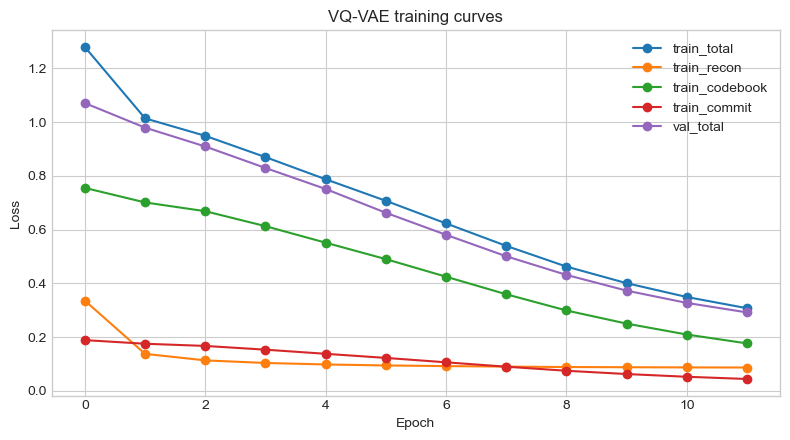

VQ-VAE test metrics:
  bce_per_image: 66.9921
  mse_per_image: 6.1125


In [13]:
# Train the stabilized VQ-VAE before we learn a prior over its discrete code maps.
vqvae = VQVAE(
    num_embeddings=LAB_CONFIG["vq_num_embeddings"],
    embedding_dim=LAB_CONFIG["vq_embedding_dim"],
    commitment_cost=LAB_CONFIG["vq_commitment_cost"],
).to(device)

print(f"VQ-VAE trainable parameters: {count_parameters(vqvae):,}")
vq_history = train_vqvae(
    vqvae,
    train_loader,
    val_loader,
    epochs=LAB_CONFIG["vqvae_epochs"],
    lr=LAB_CONFIG["vq_learning_rate"],
    weight_decay=LAB_CONFIG["weight_decay"],
    grad_clip_norm=LAB_CONFIG["vq_grad_clip_norm"],
)
plot_loss_curves(
    {
        "train_total": vq_history["train_total"],
        "train_recon": vq_history["train_recon"],
        "train_codebook": vq_history["train_codebook"],
        "train_commit": vq_history["train_commit"],
        "val_total": vq_history["val_total"],
    },
    title="VQ-VAE training curves",
)

vq_metrics = evaluate_reconstruction_metrics(vqvae, test_loader, model_type="vqvae")
print("VQ-VAE test metrics:")
for key, value in vq_metrics.items():
    print(f"  {key}: {value:.4f}")


## Section 9. VQ-VAE Evaluation and Codebook Analysis

Good reconstruction is only one part of the story. For VQ-VAE we also want to inspect the **discrete bottleneck** itself.

Questions to ask:
- Are many codebook entries used, or only a few?
- Do different digits activate different patterns of indices?
- Does the codebook appear diverse, or is it collapsing?

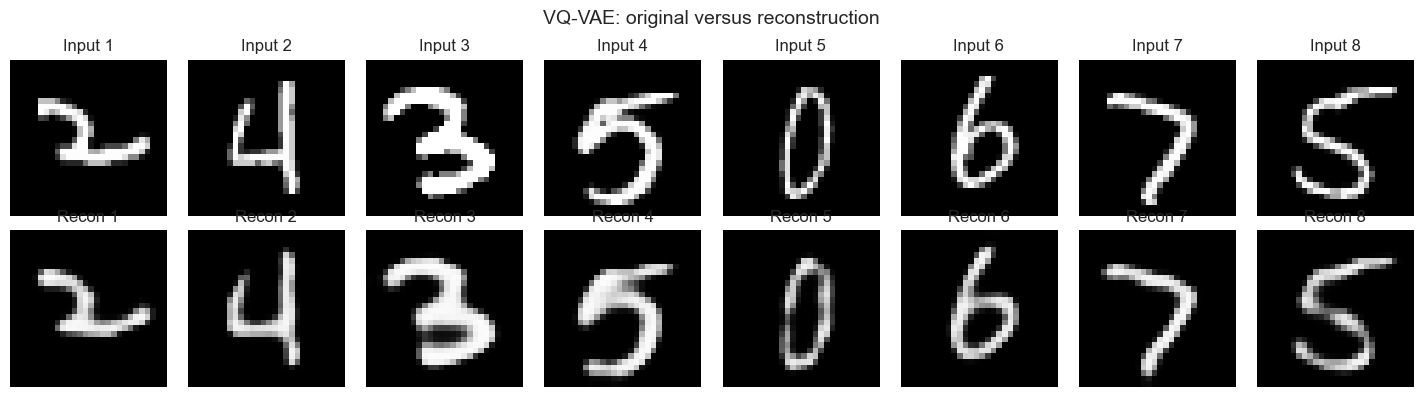

Configured VQ codebook size: 64
Codes actually used on the training set: 58 (90.6% of the codebook)


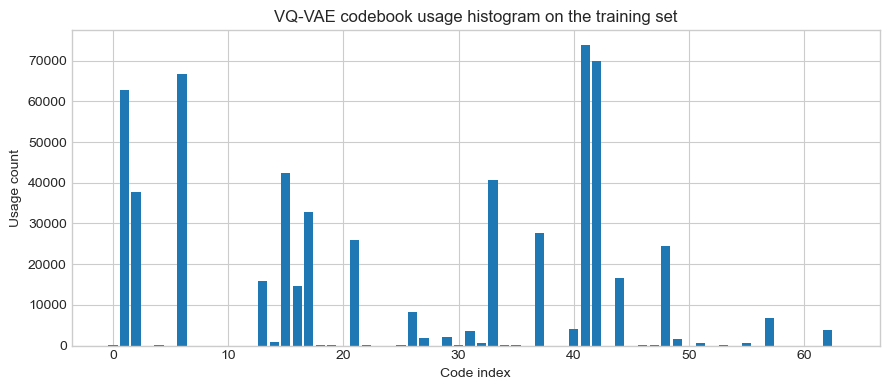

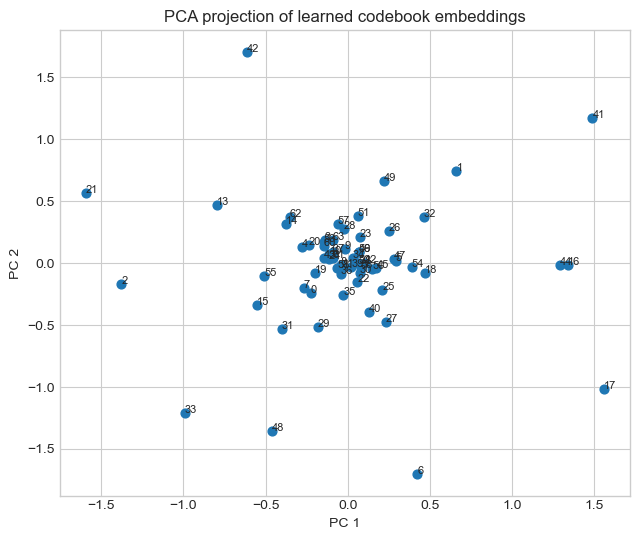

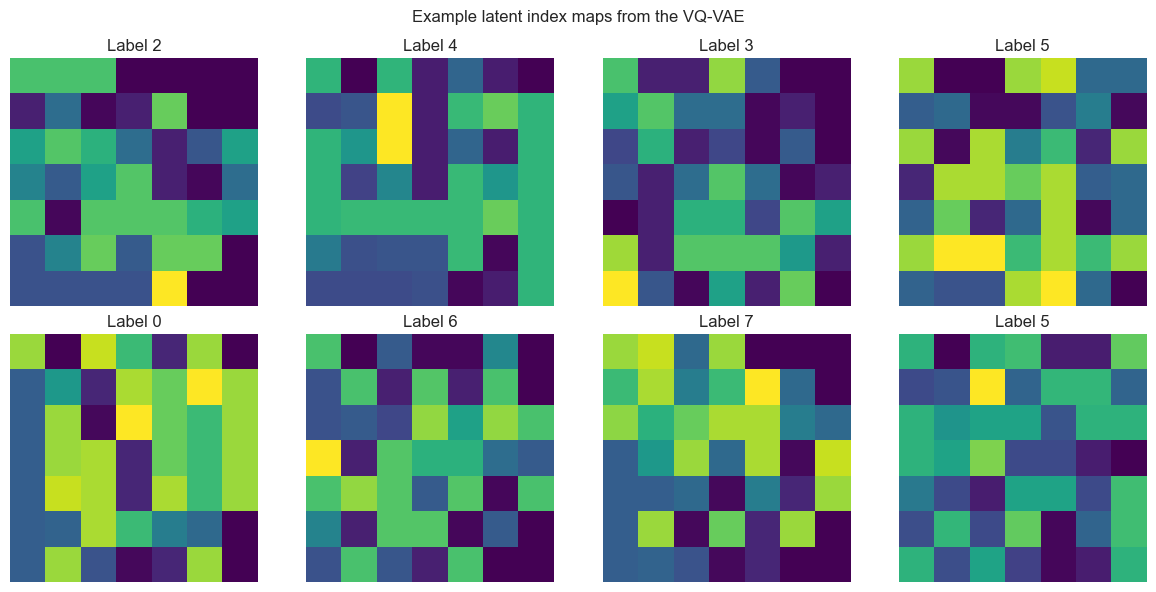

In [14]:
# This section inspects both reconstruction quality and the health of the discrete codebook.
vq_test_batch, vq_test_labels = next(iter(test_loader))
vq_test_batch = vq_test_batch.to(device)
with torch.no_grad():
    vq_recon, _, _, _, _, vq_index_map = vqvae(vq_test_batch)
plot_reconstructions(vq_test_batch, vq_recon, title="VQ-VAE: original versus reconstruction", n=8)

train_code_maps, train_code_labels = collect_vq_codes(vqvae, train_eval_loader)
code_counts = torch.bincount(train_code_maps.view(-1), minlength=LAB_CONFIG["vq_num_embeddings"]).float()
code_probs = code_counts / code_counts.sum()
used_code_ids = torch.nonzero(code_counts > 0, as_tuple=False).squeeze(1)
used_code_fraction = len(used_code_ids) / LAB_CONFIG["vq_num_embeddings"]

print(f"Configured VQ codebook size: {LAB_CONFIG['vq_num_embeddings']}")
print(f"Codes actually used on the training set: {len(used_code_ids)} ({used_code_fraction:.1%} of the codebook)")

plt.figure(figsize=(9, 4))
plt.bar(np.arange(LAB_CONFIG["vq_num_embeddings"]), code_counts.numpy())
plt.xlabel("Code index")
plt.ylabel("Usage count")
plt.title("VQ-VAE codebook usage histogram on the training set")
plt.tight_layout()
plt.show()

embedding_weights = vqvae.quantizer.embedding.weight.detach().cpu().numpy()
embedding_2d = pca_project(embedding_weights, n_components=2)
plt.figure(figsize=(6.5, 5.5))
plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1], s=40)
for i, (x, y) in enumerate(embedding_2d):
    plt.text(x, y, str(i), fontsize=8)
plt.title("PCA projection of learned codebook embeddings")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.tight_layout()
plt.show()

# Index maps show which discrete code each spatial position selected.
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(vq_index_map[i].detach().cpu(), cmap="viridis")
    ax.set_title(f"Label {int(vq_test_labels[i])}")
    ax.axis("off")
fig.suptitle("Example latent index maps from the VQ-VAE")
plt.tight_layout()
plt.show()


**Interpretation prompt**

Does the histogram suggest balanced code usage, or are a few codes dominating? If only a tiny fraction of the codebook is used, the discrete bottleneck may be under-utilized.

**Interpretation prompt**

Compare the latent index maps across digits. Are they random-looking, or do they show repeatable spatial structure?

### Checkpoint Summary
The VQ-VAE produces discrete spatial codes that can reconstruct images well. But reconstruction alone still does not tell us how to sample new code grids coherently.

## Section 10. Naive Sampling from VQ-VAE Code Indices

This section is an **illustrative experiment**.

We will try two naive strategies:
1. sample each latent position independently from a uniform distribution over code indices,
2. sample each latent position independently from the empirical frequency of code usage observed in training.

These strategies often fail because they ignore the **joint structure** across positions. A realistic latent grid is not just a bag of locally valid codes. The positions interact.

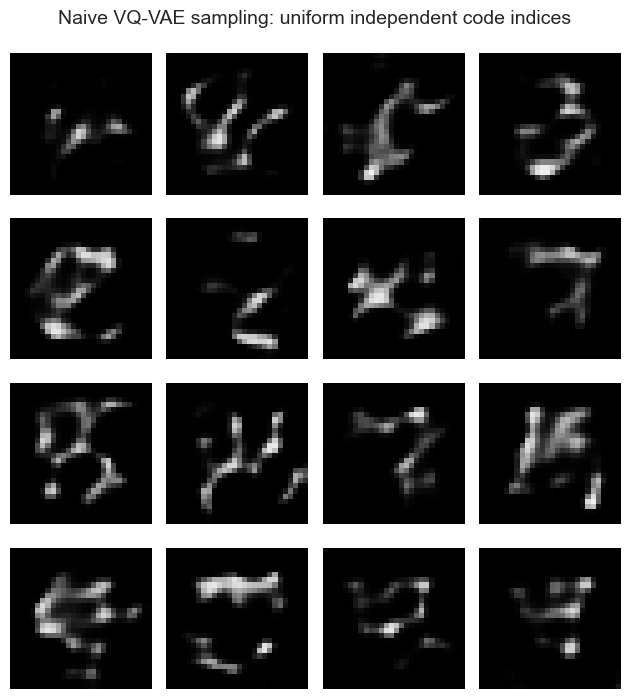

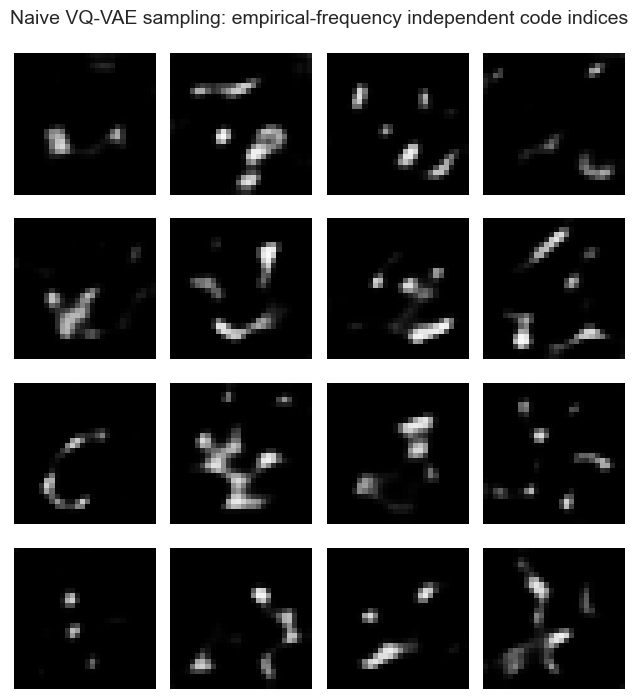

In [15]:
@torch.no_grad()
def decode_code_samples(model, index_maps, title):
    images = model.decode_indices(index_maps.to(device)).cpu()
    plot_digit_grid(images, title=title, ncols=4)


grid_h, grid_w = train_code_maps.shape[1], train_code_maps.shape[2]
num_sample_images = 16

# Uniform iid sampling ignores any structure learned between neighboring code positions.
uniform_samples = torch.randint(
    low=0,
    high=LAB_CONFIG["vq_num_embeddings"],
    size=(num_sample_images, grid_h, grid_w),
)

# Empirical-frequency sampling uses more realistic code frequencies, but still assumes independence.
empirical_samples = torch.multinomial(
    code_probs,
    num_samples=num_sample_images * grid_h * grid_w,
    replacement=True,
).view(num_sample_images, grid_h, grid_w)

decode_code_samples(vqvae, uniform_samples, title="Naive VQ-VAE sampling: uniform independent code indices")
decode_code_samples(vqvae, empirical_samples, title="Naive VQ-VAE sampling: empirical-frequency independent code indices")


**Interpretation prompt**

Why do these samples usually look worse than reconstructions, even though the individual codes came from a trained codebook?

The short answer is that the codebook tells us **what each local vector can mean**, but not **which global arrangements are likely**.

## Section 11. Build a Simple Autoregressive Prior over VQ-VAE Codes

Students in this course already know autoregressive modeling, so now we combine that knowledge with the VQ-VAE bottleneck.

The plan is simple:
1. encode each image into a $7 \times 7$ latent index grid,
2. flatten the grid into a sequence of length $49$,
3. train a GRU to predict the next code index,
4. sample a full code sequence autoregressively,
5. reshape it back into a grid and decode it.

This differs from naive sampling because the model now learns **dependencies among positions**.


In [16]:
class CodeSequenceDataset(Dataset):
    def __init__(self, code_maps, num_codes):
        self.sequences = code_maps.view(code_maps.size(0), -1).long()
        self.bos_token = num_codes
        self.num_codes = num_codes
        self.seq_len = self.sequences.size(1)

    def __len__(self):
        return self.sequences.size(0)

    def __getitem__(self, idx):
        target = self.sequences[idx]
        # Teacher forcing: input is BOS + previous tokens, target is the next-token sequence.
        input_seq = torch.cat([torch.tensor([self.bos_token]), target[:-1]], dim=0)
        return input_seq, target


class GRUPrior(nn.Module):
    def __init__(self, num_codes, seq_len, embed_dim=192, hidden_dim=384, num_layers=3, dropout=0.15):
        super().__init__()
        self.num_codes = num_codes
        self.bos_token = num_codes
        self.seq_len = seq_len
        self.token_embedding = nn.Embedding(num_codes + 1, embed_dim)
        # Positional embeddings make it easier for the GRU to distinguish early and late locations
        # in the flattened 7x7 latent grid.
        self.position_embedding = nn.Embedding(seq_len, embed_dim)
        self.input_dropout = nn.Dropout(dropout)
        self.gru = nn.GRU(
            embed_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        # A slightly richer output head usually helps the GRU fit discrete code sequences better.
        self.hidden_norm = nn.LayerNorm(hidden_dim)
        self.pre_logits = nn.Linear(hidden_dim, embed_dim)
        self.pre_logits_norm = nn.LayerNorm(embed_dim)
        self.output_bias = nn.Parameter(torch.zeros(num_codes))

    def forward(self, tokens, hidden=None):
        positions = torch.arange(tokens.size(1), device=tokens.device).unsqueeze(0)
        x = self.token_embedding(tokens) + self.position_embedding(positions)
        x = self.input_dropout(x)
        out, hidden = self.gru(x, hidden)
        out = self.hidden_norm(out)
        out = F.gelu(self.pre_logits(out))
        out = self.pre_logits_norm(out)
        # Weight tying often improves token models because input and output embeddings
        # share the same semantic space.
        logits = F.linear(out, self.token_embedding.weight[: self.num_codes], self.output_bias)
        return logits, hidden


def train_prior(model, train_loader, val_loader, epochs=12, lr=8e-4, grad_clip_norm=1.0):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    history = {"train_ce": [], "val_ce": [], "train_ppl": [], "val_ppl": []}
    for epoch in range(epochs):
        model.train()
        total_train = 0.0
        train_n = 0
        for tokens, targets in train_loader:
            tokens = tokens.to(device)
            targets = targets.to(device)
            logits, _ = model(tokens)
            loss = F.cross_entropy(logits.reshape(-1, model.num_codes), targets.reshape(-1))

            optimizer.zero_grad()
            loss.backward()
            if grad_clip_norm is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip_norm)
            optimizer.step()

            batch_size = tokens.size(0)
            total_train += loss.item() * batch_size
            train_n += batch_size

        model.eval()
        total_val = 0.0
        val_n = 0
        with torch.no_grad():
            for tokens, targets in val_loader:
                tokens = tokens.to(device)
                targets = targets.to(device)
                logits, _ = model(tokens)
                loss = F.cross_entropy(logits.reshape(-1, model.num_codes), targets.reshape(-1))
                batch_size = tokens.size(0)
                total_val += loss.item() * batch_size
                val_n += batch_size

        scheduler.step()
        train_ce = total_train / train_n
        val_ce = total_val / val_n
        history["train_ce"].append(train_ce)
        history["val_ce"].append(val_ce)
        history["train_ppl"].append(float(np.exp(train_ce)))
        history["val_ppl"].append(float(np.exp(val_ce)))
        print(
            f"[Prior] Epoch {epoch + 1:02d}/{epochs} | "
            f"train CE: {train_ce:.4f} | val CE: {val_ce:.4f} | "
            f"train ppl: {history['train_ppl'][-1]:.2f} | val ppl: {history['val_ppl'][-1]:.2f}"
        )
    return history


@torch.no_grad()
def sample_from_prior(model, num_samples, seq_len, temperature=1.0, top_k=None, allowed_code_mask=None):
    model.eval()
    hidden = None
    current = torch.full((num_samples, 1), model.bos_token, dtype=torch.long, device=device)
    sampled = []
    for step in range(seq_len):
        logits, hidden = model(current[:, -1:], hidden)
        logits = logits[:, -1, :] / temperature

        # Optionally suppress codes that never appeared in the training set.
        if allowed_code_mask is not None:
            logits = logits.masked_fill(~allowed_code_mask.unsqueeze(0), float("-inf"))

        # Top-k sampling drops very unlikely tokens and usually produces cleaner code sequences.
        if top_k is not None and top_k < logits.size(-1):
            top_values, top_indices = torch.topk(logits, k=top_k, dim=-1)
            filtered = torch.full_like(logits, float("-inf"))
            filtered.scatter_(1, top_indices, top_values)
            logits = filtered

        probs = torch.softmax(logits, dim=-1)
        next_token = torch.multinomial(probs, num_samples=1)
        sampled.append(next_token)
        current = torch.cat([current, next_token], dim=1)
    return torch.cat(sampled, dim=1)


Original codebook size: 64
Codes seen in training set: 58
GRU prior trainable parameters: 2,536,960
[Prior] Epoch 01/20 | train CE: 6.4212 | val CE: 2.2372 | train ppl: 614.72 | val ppl: 9.37
[Prior] Epoch 02/20 | train CE: 2.0169 | val CE: 1.7865 | train ppl: 7.51 | val ppl: 5.97
[Prior] Epoch 03/20 | train CE: 1.7262 | val CE: 1.6595 | train ppl: 5.62 | val ppl: 5.26
[Prior] Epoch 04/20 | train CE: 1.5895 | val CE: 1.5282 | train ppl: 4.90 | val ppl: 4.61
[Prior] Epoch 05/20 | train CE: 1.5010 | val CE: 1.4708 | train ppl: 4.49 | val ppl: 4.35
[Prior] Epoch 06/20 | train CE: 1.4372 | val CE: 1.3870 | train ppl: 4.21 | val ppl: 4.00
[Prior] Epoch 07/20 | train CE: 1.3856 | val CE: 1.3316 | train ppl: 4.00 | val ppl: 3.79
[Prior] Epoch 08/20 | train CE: 1.3439 | val CE: 1.3113 | train ppl: 3.83 | val ppl: 3.71
[Prior] Epoch 09/20 | train CE: 1.3138 | val CE: 1.2902 | train ppl: 3.72 | val ppl: 3.63
[Prior] Epoch 10/20 | train CE: 1.2835 | val CE: 1.2761 | train ppl: 3.61 | val ppl: 3.5

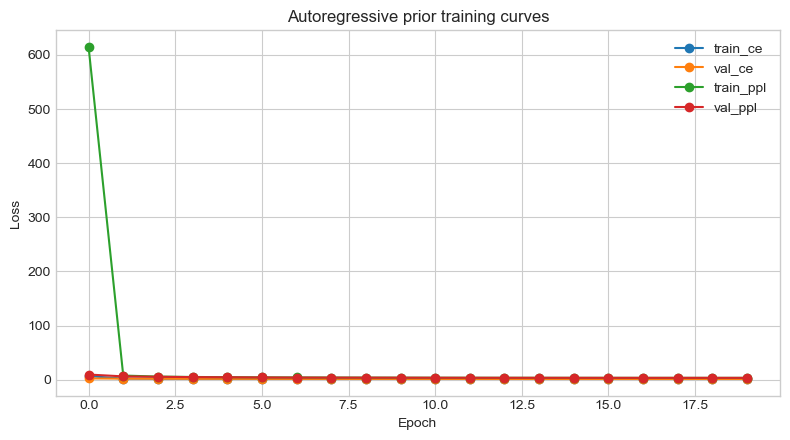

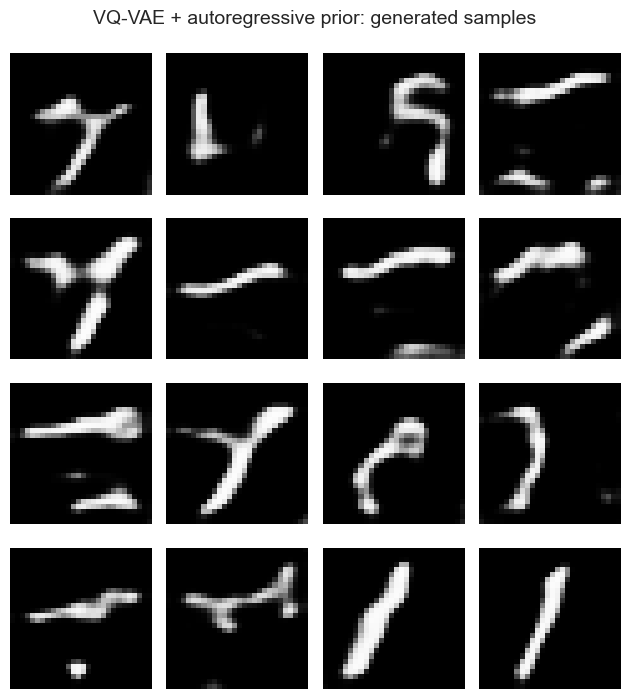

In [17]:
train_code_maps, _ = collect_vq_codes(vqvae, train_eval_loader)
val_code_maps, _ = collect_vq_codes(vqvae, val_loader)

train_code_counts = torch.bincount(train_code_maps.view(-1), minlength=LAB_CONFIG["vq_num_embeddings"])
seen_code_mask = train_code_counts > 0
sampling_top_k = min(LAB_CONFIG["prior_top_k"], LAB_CONFIG["vq_num_embeddings"])

print(f"Original codebook size: {LAB_CONFIG['vq_num_embeddings']}")
print(f"Codes seen in training set: {int(seen_code_mask.sum().item())}")

prior_train_dataset = CodeSequenceDataset(train_code_maps, LAB_CONFIG["vq_num_embeddings"])
prior_val_dataset = CodeSequenceDataset(val_code_maps, LAB_CONFIG["vq_num_embeddings"])

# A moderately large batch works well here because the prior is trained on short token sequences.
prior_train_loader = DataLoader(prior_train_dataset, batch_size=256, shuffle=True)
prior_val_loader = DataLoader(prior_val_dataset, batch_size=256, shuffle=False)

prior = GRUPrior(
    num_codes=LAB_CONFIG["vq_num_embeddings"],
    seq_len=prior_train_dataset.seq_len,
    embed_dim=LAB_CONFIG["prior_embed_dim"],
    hidden_dim=LAB_CONFIG["prior_hidden_dim"],
    num_layers=LAB_CONFIG["prior_num_layers"],
    dropout=LAB_CONFIG["prior_dropout"],
).to(device)

print(f"GRU prior trainable parameters: {count_parameters(prior):,}")
prior_history = train_prior(
    prior,
    prior_train_loader,
    prior_val_loader,
    epochs=LAB_CONFIG["prior_epochs"],
    lr=LAB_CONFIG["prior_learning_rate"],
    grad_clip_norm=LAB_CONFIG["prior_grad_clip_norm"],
)
plot_loss_curves(
    {
        "train_ce": prior_history["train_ce"],
        "val_ce": prior_history["val_ce"],
        "train_ppl": prior_history["train_ppl"],
        "val_ppl": prior_history["val_ppl"],
    },
    title="Autoregressive prior training curves",
)

sampled_sequences = sample_from_prior(
    prior,
    num_samples=16,
    seq_len=train_code_maps[0].numel(),
    temperature=LAB_CONFIG["prior_temperature"],
    top_k=sampling_top_k,
    allowed_code_mask=seen_code_mask.to(device),
)
sampled_index_maps = sampled_sequences.view(-1, grid_h, grid_w)

with torch.no_grad():
    prior_generated = vqvae.decode_indices(sampled_index_maps.to(device)).cpu()
plot_digit_grid(prior_generated, title="VQ-VAE + autoregressive prior: generated samples", ncols=4)


**Interpretation prompt**

Compare these samples with the naive iid samples from the previous section. What improved? Even if the digits are not perfect, do they at least look more globally coherent?

### Checkpoint Summary
The learned autoregressive prior models dependencies between code positions, which is exactly what naive independent sampling misses. This is the missing generative component for the VQ-VAE pipeline.

## Section 12. Comprehensive Comparison: AE vs VAE vs VQ-VAE vs VQ-VAE+Prior

We now gather the main results into one place.

Keep the evaluation logic straight:
- **AE**: strong reconstruction baseline, weak principled generation.
- **VAE**: slightly softer reconstructions, but principled Gaussian latent sampling.
- **VQ-VAE**: strong discrete reconstructions, but sampling needs a prior.
- **VQ-VAE + prior**: full generative pipeline over discrete latents.

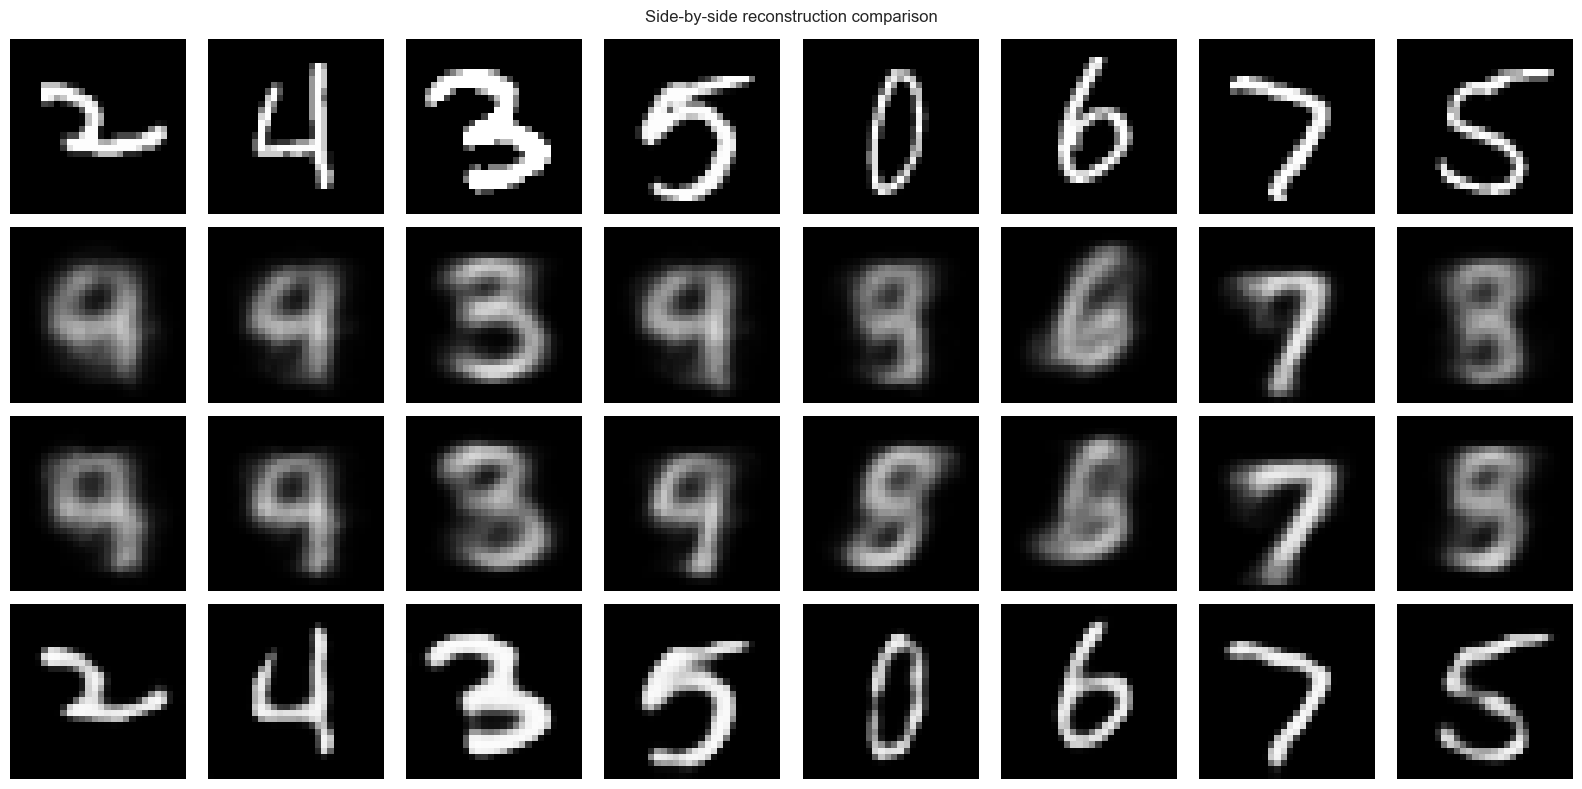

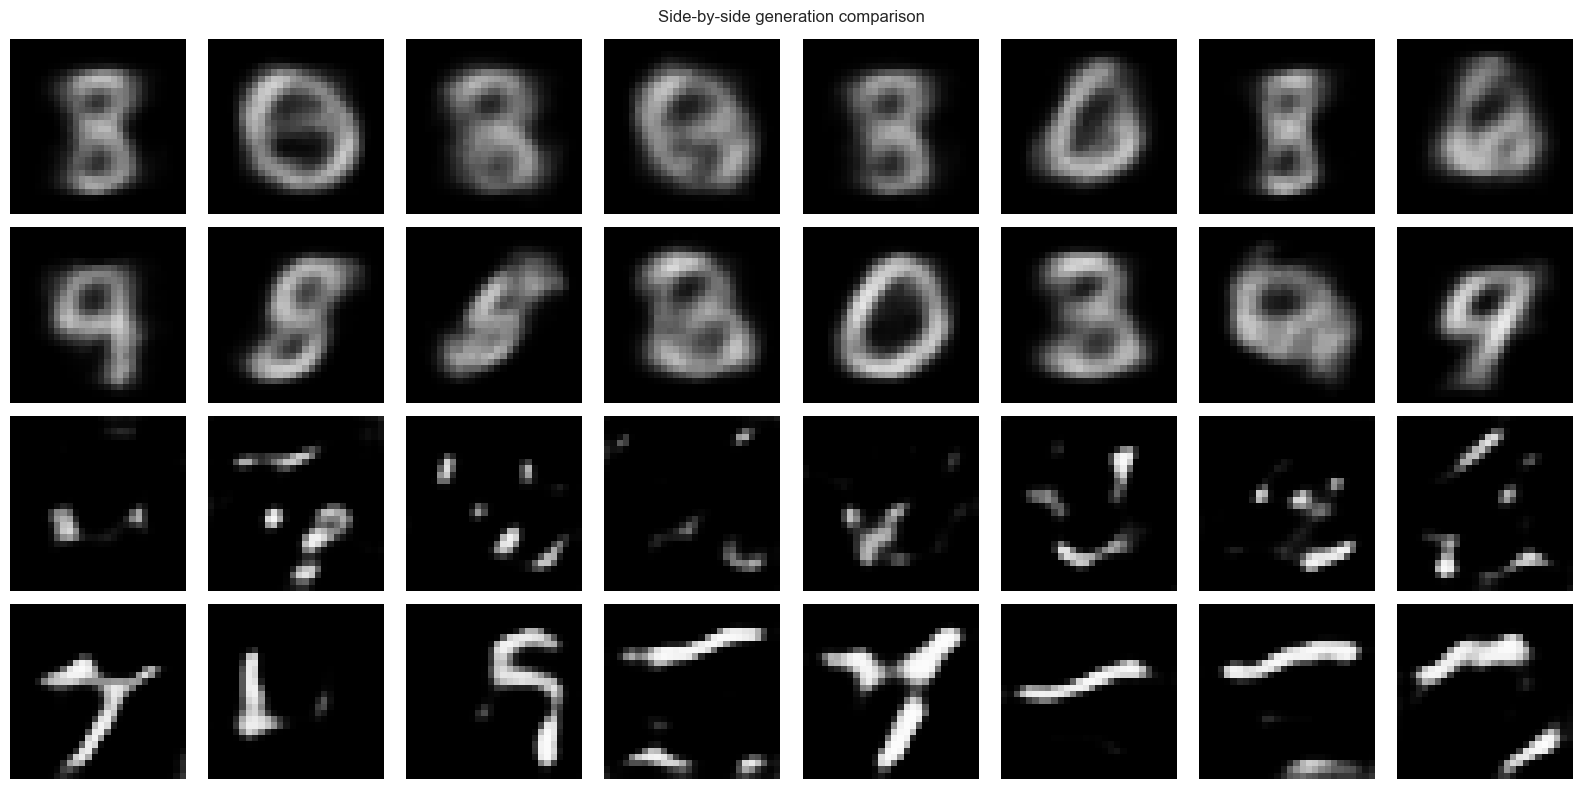


| Model | Latent type | Easy random sampling? | Test BCE/image | Test MSE/image | Main strength | Main limitation |
|---|---|---:|---:|---:|---|---|
| AE | Continuous, deterministic | No | 154.060 | 35.672 | Strong reconstruction baseline and easy latent visualization | No principled prior, random latent decoding is unreliable |
| VAE | Continuous, probabilistic | Yes | 152.557 | 35.247 | Structured latent space with simple Gaussian sampling | Reconstructions can be blurrier |
| VQ-VAE | Discrete spatial code grid | Not by itself | 66.992 | 6.113 | Sharp discrete bottleneck and code analysis | Needs a separate prior for good generation |
| VQ-VAE + Prior | Discrete spatial code grid + autoregressive prior | Yes, after learning prior | same decoder as VQ-VAE | same decoder as VQ-VAE | Better generation by modeling code dependencies | More moving parts and longer training pipeline |


In [18]:
comparison_inputs, comparison_labels = next(iter(test_loader))
comparison_inputs = comparison_inputs[:8].to(device)

with torch.no_grad():
    ae_comp_recon = ae(comparison_inputs)
    vae_comp_recon, _, _ = vae(comparison_inputs, sample_posterior=False)
    vq_comp_recon, _, _, _, _, _ = vqvae(comparison_inputs)

    # Each row below uses the model's own native sampling mechanism.
    ae_random_z = torch.randn(8, LAB_CONFIG["latent_dim_ae"], device=device)
    ae_random_samples = ae.decode(ae_random_z)
    vae_random_samples = vae.sample_prior(8)
    naive_best_samples = vqvae.decode_indices(empirical_samples[:8].to(device))
    prior_samples_8 = prior_generated[:8].to(device)

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
rows = [
    (comparison_inputs, "Input"),
    (ae_comp_recon, "AE recon"),
    (vae_comp_recon, "VAE recon"),
    (vq_comp_recon, "VQ recon"),
]
for row_idx, (images, row_title) in enumerate(rows):
    for col in range(8):
        axes[row_idx, col].imshow(images[col, 0].detach().cpu(), cmap="gray", vmin=0.0, vmax=1.0)
        axes[row_idx, col].axis("off")
        if col == 0:
            axes[row_idx, col].set_ylabel(row_title, fontsize=11)
plt.suptitle("Side-by-side reconstruction comparison")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
gen_rows = [
    (ae_random_samples, "AE random z"),
    (vae_random_samples, "VAE prior"),
    (naive_best_samples, "VQ naive iid"),
    (prior_samples_8, "VQ + prior"),
]
for row_idx, (images, row_title) in enumerate(gen_rows):
    for col in range(8):
        axes[row_idx, col].imshow(images[col, 0].detach().cpu(), cmap="gray", vmin=0.0, vmax=1.0)
        axes[row_idx, col].axis("off")
        if col == 0:
            axes[row_idx, col].set_ylabel(row_title, fontsize=11)
plt.suptitle("Side-by-side generation comparison")
plt.tight_layout()
plt.show()

ae_metrics = evaluate_reconstruction_metrics(ae, test_loader, model_type="ae")

summary_table = f"""
| Model | Latent type | Easy random sampling? | Test BCE/image | Test MSE/image | Main strength | Main limitation |
|---|---|---:|---:|---:|---|---|
| AE | Continuous, deterministic | No | {ae_metrics['bce_per_image']:.3f} | {ae_metrics['mse_per_image']:.3f} | Strong reconstruction baseline and easy latent visualization | No principled prior, random latent decoding is unreliable |
| VAE | Continuous, probabilistic | Yes | {vae_metrics['bce_per_image']:.3f} | {vae_metrics['mse_per_image']:.3f} | Structured latent space with simple Gaussian sampling | Reconstructions can be blurrier |
| VQ-VAE | Discrete spatial code grid | Not by itself | {vq_metrics['bce_per_image']:.3f} | {vq_metrics['mse_per_image']:.3f} | Sharp discrete bottleneck and code analysis | Needs a separate prior for good generation |
| VQ-VAE + Prior | Discrete spatial code grid + autoregressive prior | Yes, after learning prior | same decoder as VQ-VAE | same decoder as VQ-VAE | Better generation by modeling code dependencies | More moving parts and longer training pipeline |
"""
display(Markdown(summary_table))


**Interpretation prompt**

Which model would you choose if your goal were primarily compression and reconstruction? Which would you choose if your goal were generation from scratch? Which trade-offs are you willing to make?

## Section 13. Summary and Conclusion

We have now built a full conceptual chain:

- **AE** learns to compress and reconstruct, but does not shape latent space for principled sampling.
- **VAE** regularizes the latent representation so sampling from a Gaussian prior becomes meaningful.
- **VQ-VAE** replaces continuous latents with discrete code indices, giving a token-like bottleneck.
- **VQ-VAE + learned prior** turns those discrete codes into a true generative pipeline by modeling their joint structure.

## What you should now be able to explain
1. Why reconstruction quality alone is not enough for generative modeling.
2. How the KL term changes the geometry of the VAE latent space.
3. Why quantization creates a discrete bottleneck in VQ-VAE.
4. Why naive iid code sampling fails for VQ-VAE.
5. Why an autoregressive prior helps generate coherent code sequences.

## Optional extension ideas
- Increase the VQ-VAE codebook size and inspect code usage again.
- Replace the GRU prior with a small Transformer decoder.
- Try a convolutional VAE and compare with the fully connected VAE.
- Explore conditional generation by digit label.
- Compare $\beta$-VAE settings more systematically.

If you can tell the story $\mathrm{AE} \rightarrow \mathrm{VAE} \rightarrow \mathrm{VQ\text{-}VAE} \rightarrow \mathrm{VQ\text{-}VAE\ with\ prior}$ in your own words, then you have understood the central conceptual arc of this lab.
